In [166]:
import pandas as pd
# load the dataset
PATH_TO_DATA = './Titanic-Dataset.csv'
df = pd.read_csv(PATH_TO_DATA)
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### The dataset consist of the following column
- **PassengerId**: A unique, sequential integer assigned to each passenger.
- **Survived**: The target variable used for predictions. (0 = Did not survive, 1 = Survived).
- **Pclass**: The ticket class representing the socio-economic status of the passenger. (1 = 1st Class / Upper, 2 = 2nd Class / Middle, 3 = 3rd Class / Lower).
- **Name**: The full name of the passenger, including titles (e.g., Mr., Mrs., Miss, Master).
- **Sex**: The gender of the passenger (Male or Female).Age: The age of the passenger in years. Fractional values are used for infants (e.g., 0.92 for a 11-month-old).
- **SibSp**: The number of siblings (brother, sister, stepbrother, stepsister) or spouses (husband, wife) aboard the Titanic.
- **Parch**: The number of parents (mother, father) or children (daughter, son, stepdaughter, stepson) aboard the Titanic.
- **Ticket**: The alphanumeric ticket number.
- **Fare**: The passenger fare, typically recorded in British Pounds (£).
- **Cabin**: The alphanumeric cabin number where the passenger stayed.
- **Embarked**: The port where the passenger boarded the ship. (C = Cherbourg, Q = Queenstown, S = Southampton).

In [167]:
# check null values and traet them 

col_summary = pd.DataFrame({
    'Null Value': df.isnull().sum(),
    'data_type': df.dtypes,
    "Missing Percentage": (df.isnull().sum() / len(df)) * 100
})
col_summary

,Null Value,data_type,Missing Percentage
PassengerId,0,int64,0.000000
Survived,0,int64,0.000000
Pclass,0,int64,0.000000
Name,0,str,0.000000
Sex,0,str,0.000000
Age,177,float64,19.865320
SibSp,0,int64,0.000000
Parch,0,int64,0.000000
Ticket,0,str,0.000000
Fare,0,float64,0.000000


### Data Cleaning

In [168]:
# handle Missing values
cleaned_df = df.copy(deep=True)
missing_col = ["Age", "Cabin", "Embarked"]
for col  in missing_col:
    if col == "Age":
        cleaned_df[col] = cleaned_df[col].fillna(cleaned_df[col].median())
    elif col == "Cabin":
        cleaned_df.drop(columns=[col], inplace=True)
    elif col == "Embarked":
        cleaned_df[col] = cleaned_df[col].fillna(cleaned_df[col].mode()[0])
cleaned_df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [169]:
cleaned_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [170]:
# adding discoverable insights to the dataset
cleaned_df["nobel"] = cleaned_df["Fare"].apply(lambda x: 1 if x > 100 else 0)
cleaned_df["family_size"] = cleaned_df["SibSp"] + cleaned_df["Parch"] + 1
cleaned_df["is_alone"] = cleaned_df["family_size"].apply(lambda x: 1 if x == 1 else 0)

In [171]:
# encode categorical data
cleaned_df["Sex"] = cleaned_df["Sex"].map({"male": 0, "female": 1})
cleaned_df["Embarked"] = cleaned_df["Embarked"].map({"S": 0, "C": 1, "Q": 2})

In [172]:
# remove unwanted data
cleaned_df.drop(columns=["PassengerId", "Name", "Ticket", "SibSp", "Parch"], inplace=True)

In [173]:
cleaned_df.head()

,Survived,Pclass,Sex,Age,Fare,Embarked,nobel,family_size,is_alone
0,0,3,0,22.0,7.2500,0,0,2,0
1,1,1,1,38.0,71.2833,1,0,2,0
2,1,3,1,26.0,7.9250,0,0,1,1
3,1,1,1,35.0,53.1000,0,0,2,0
4,0,3,0,35.0,8.0500,0,0,1,1


In [174]:
# measuring skewness and kurtosis of the dataset
skewness = cleaned_df.skew()
kurtosis = cleaned_df.kurtosis()

print(f"Skewness:\n{skewness}\n Krutosis:\n{kurtosis}")

Skewness:
Survived       0.478523
Pclass        -0.630548
Sex            0.618921
Age            0.510245
Fare           4.787317
Embarked       1.543397
nobel          3.731142
family_size    2.727441
is_alone      -0.420431
dtype: float64
 Krutosis:
Survived       -1.775005
Pclass         -1.280015
Sex            -1.620580
Age             0.993871
Fare           33.398141
Embarked        1.105629
nobel          11.948237
family_size     9.159666
is_alone       -1.827345
dtype: float64


# Based on skewness
- Fare - Right skew so using log-transformation on this
- Parch - Right skew so using log-transformation on this
- Sib_Sp - Right skew so using log-transformation on this
- family size - Right Skew using log-transformation on this

In [175]:
import numpy as np

cleaned_df[["Fare", "family_size"]] = np.log1p(cleaned_df[["Fare","family_size"]])


In [176]:
# measuring skewness and kurtosis of the dataset
new_skewness = cleaned_df.skew()
new_kurtosis = cleaned_df.kurtosis()

print(f"Skewness:\n{new_skewness}\n Kurtosis:\n{new_kurtosis}")

Skewness:
Survived       0.478523
Pclass        -0.630548
Sex            0.618921
Age            0.510245
Fare           0.394928
Embarked       1.543397
nobel          3.731142
family_size    1.472759
is_alone      -0.420431
dtype: float64
 Kurtosis:
Survived       -1.775005
Pclass         -1.280015
Sex            -1.620580
Age             0.993871
Fare            0.976142
Embarked        1.105629
nobel          11.948237
family_size     1.605856
is_alone       -1.827345
dtype: float64


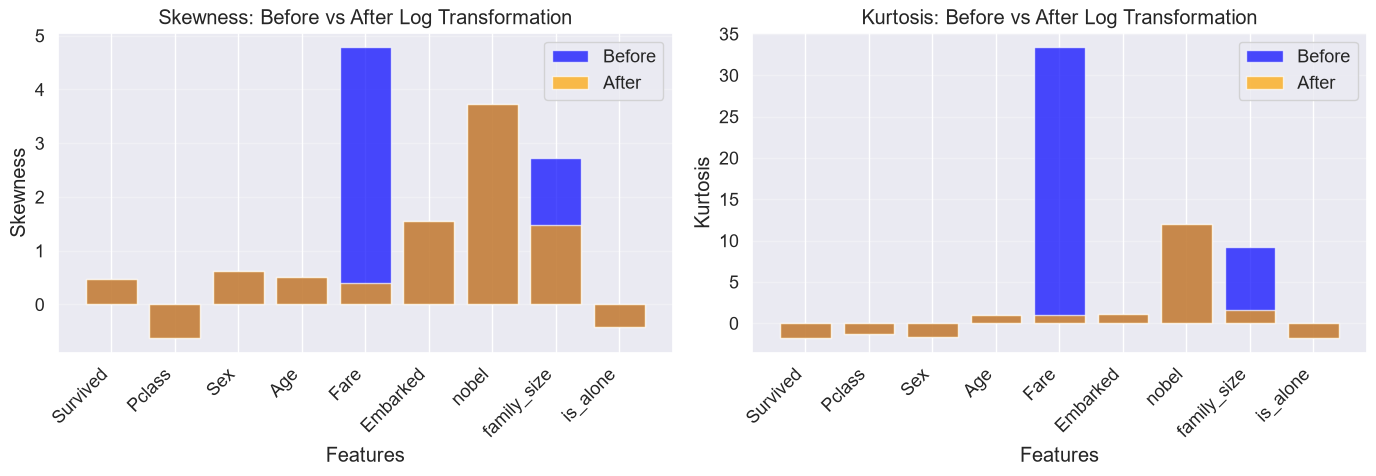

In [177]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(len(skewness)), skewness, alpha=0.7, label='Before', color='blue')
axes[0].bar(range(len(new_skewness)), new_skewness, alpha=0.7, label='After', color='orange')
axes[0].set_xlabel('Features')
axes[0].set_ylabel('Skewness')
axes[0].set_title('Skewness: Before vs After Log Transformation')
axes[0].set_xticks(range(len(skewness)))
axes[0].set_xticklabels(skewness.index, rotation=45, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(range(len(kurtosis)), kurtosis, alpha=0.7, label='Before', color='blue')
axes[1].bar(range(len(new_kurtosis)), new_kurtosis, alpha=0.7, label='After', color='orange')
axes[1].set_xlabel('Features')
axes[1].set_ylabel('Kurtosis')
axes[1].set_title('Kurtosis: Before vs After Log Transformation')
axes[1].set_xticks(range(len(kurtosis)))
axes[1].set_xticklabels(kurtosis.index, rotation=45, ha='right')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [178]:
# Quick summary of data
cleaned_df.describe()

,Survived,Pclass,Sex,Age,Fare,Embarked,nobel,family_size,is_alone
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,0.352413,29.361582,2.962246,0.361392,0.059484,0.967890,0.602694
std,0.486592,0.836071,0.477990,13.019697,0.969048,0.635673,0.236661,0.402669,0.489615
min,0.000000,1.000000,0.000000,0.420000,0.000000,0.000000,0.000000,0.693147,0.000000
25%,0.000000,2.000000,0.000000,22.000000,2.187218,0.000000,0.000000,0.693147,0.000000
50%,0.000000,3.000000,0.000000,28.000000,2.737881,0.000000,0.000000,0.693147,1.000000
75%,1.000000,3.000000,1.000000,35.000000,3.465736,1.000000,0.000000,1.098612,1.000000
max,1.000000,3.000000,1.000000,80.000000,6.240917,2.000000,1.000000,2.484907,1.000000


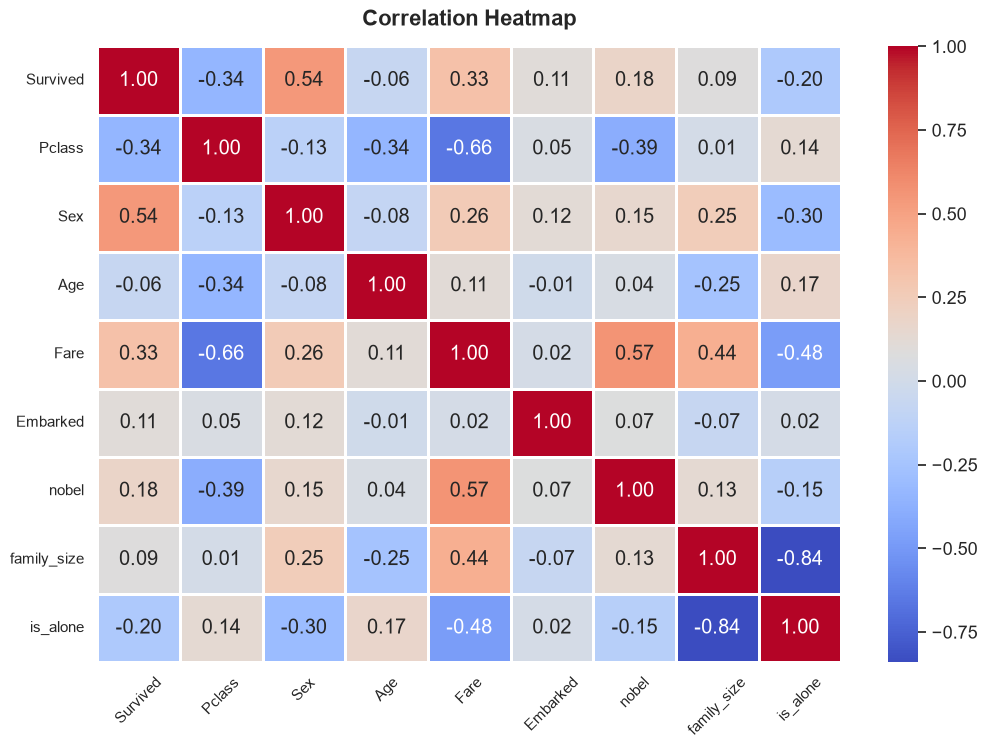

In [179]:
# EDA plots
# Coorelation heatmap
import seaborn as sns

corr = cleaned_df.corr()

plt.figure(figsize=(12, 8))
sns.set_theme(font_scale=1.2)
ax = sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=1)

ax.set_title('Correlation Heatmap', fontsize=16, pad=15, weight='bold')
plt.xticks(fontsize=11, rotation=45)
plt.yticks(fontsize=11, rotation=0)

plt.show()
 

# Observation from Correlation heatmap

- Survived and Sex: Has a strong positive correlation as women were prioritized for lifeboats.
- Survived and Pclass: Has a negative correlation higher passenger class, indicated by 1, correlates with higher survival (Higher class number lower socioeconomical status).
- Survived and Nobel: Has a positive correlation stating nobels are given priority in survival 
- Fare and Pclass: Has a strong negative correlation first-class tickets cost more.
- Family and Survived vs Alone and Survived: Alone and Survived has a negative whereas Family and survived has positive stating that the persons with Family had escaped more than the persons who were alone

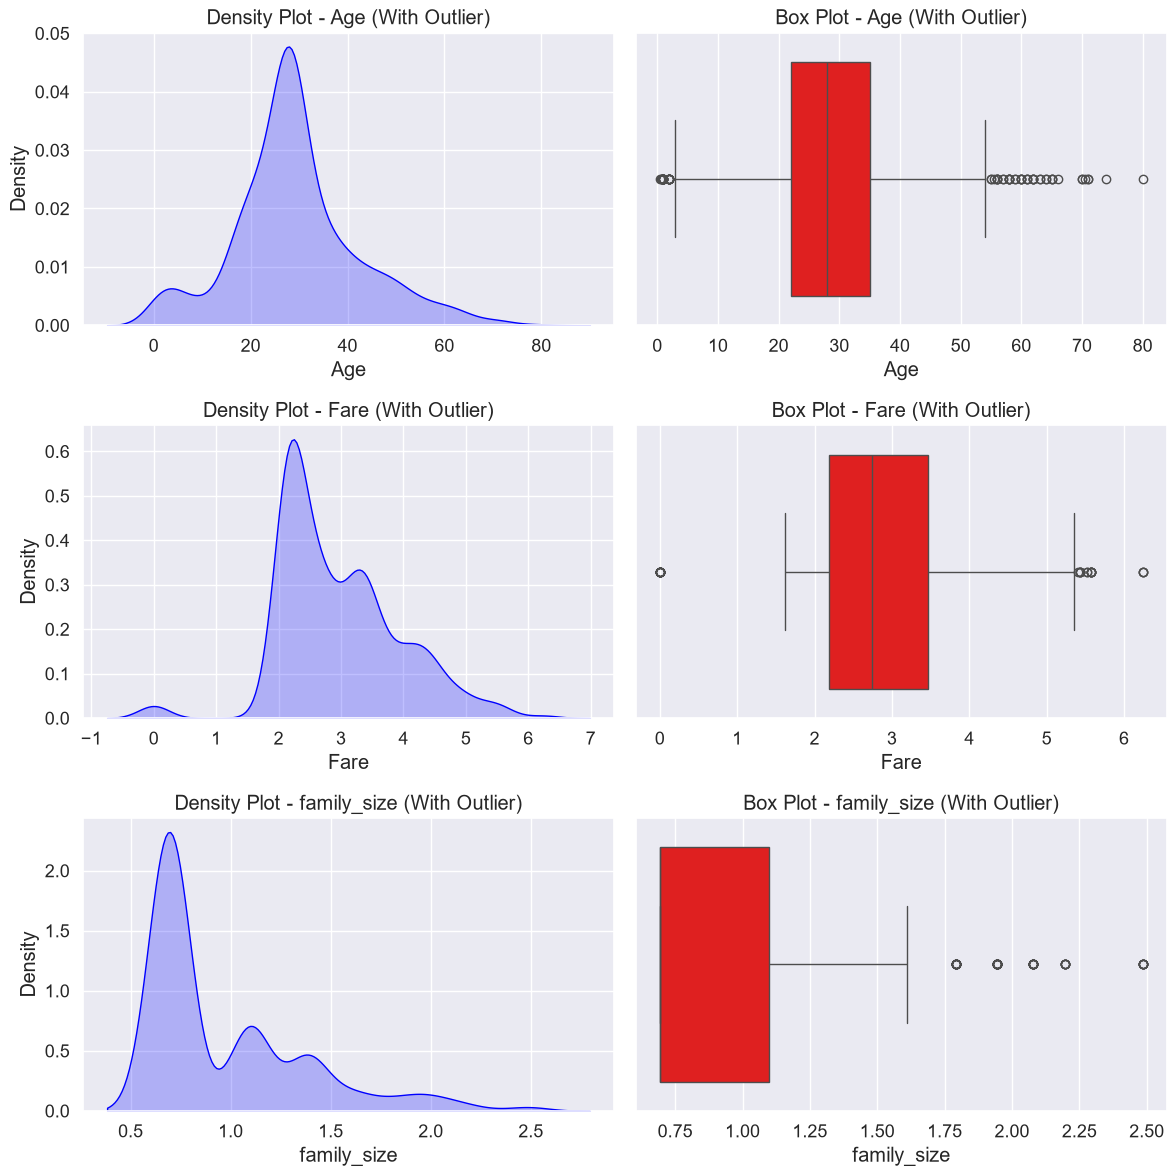

<Figure size 640x480 with 0 Axes>

In [180]:

continuous_cols = ['Age', 'Fare', 'family_size']
fig, axes = plt.subplots(len(continuous_cols), 2, figsize=(12, 4 * len(continuous_cols)))

if len(continuous_cols) == 1:
    axes = axes.reshape(1, 2)

for i, c in enumerate(continuous_cols):
    sns.kdeplot(data=cleaned_df, x=c, fill=True, ax=axes[i, 0], color="blue")
    axes[i, 0].set_title(f"Density Plot - {c} (With Outlier)")
    
    sns.boxplot(x=cleaned_df[c], ax=axes[i, 1], color="red")
    axes[i, 1].set_title(f"Box Plot - {c} (With Outlier)")
    axes[i, 1].set_xlabel(c)

plt.tight_layout()
plt.show()
plt.tight_layout()
plt.show()

In [181]:
Q1_age = cleaned_df['Age'].quantile(0.25)
Q3_age = cleaned_df['Age'].quantile(0.75)
IQR_age = Q3_age - Q1_age

lower_age = Q1_age - 1.5 * IQR_age
upper_age = Q3_age + 1.5 * IQR_age

cleaned_df = cleaned_df[(cleaned_df['Age'] >= lower_age) & (cleaned_df['Age'] <= upper_age)]

skewed_cols = ['Fare', 'family_size']

for col in skewed_cols:
    Q1 = cleaned_df[col].quantile(0.25)
    Q3 = cleaned_df[col].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR
    cleaned_df[col] = np.clip(cleaned_df[col], a_min=None, a_max=upper_bound)

print(f"Dataset shape after handling outliers: {cleaned_df.shape}")


Dataset shape after handling outliers: (825, 9)


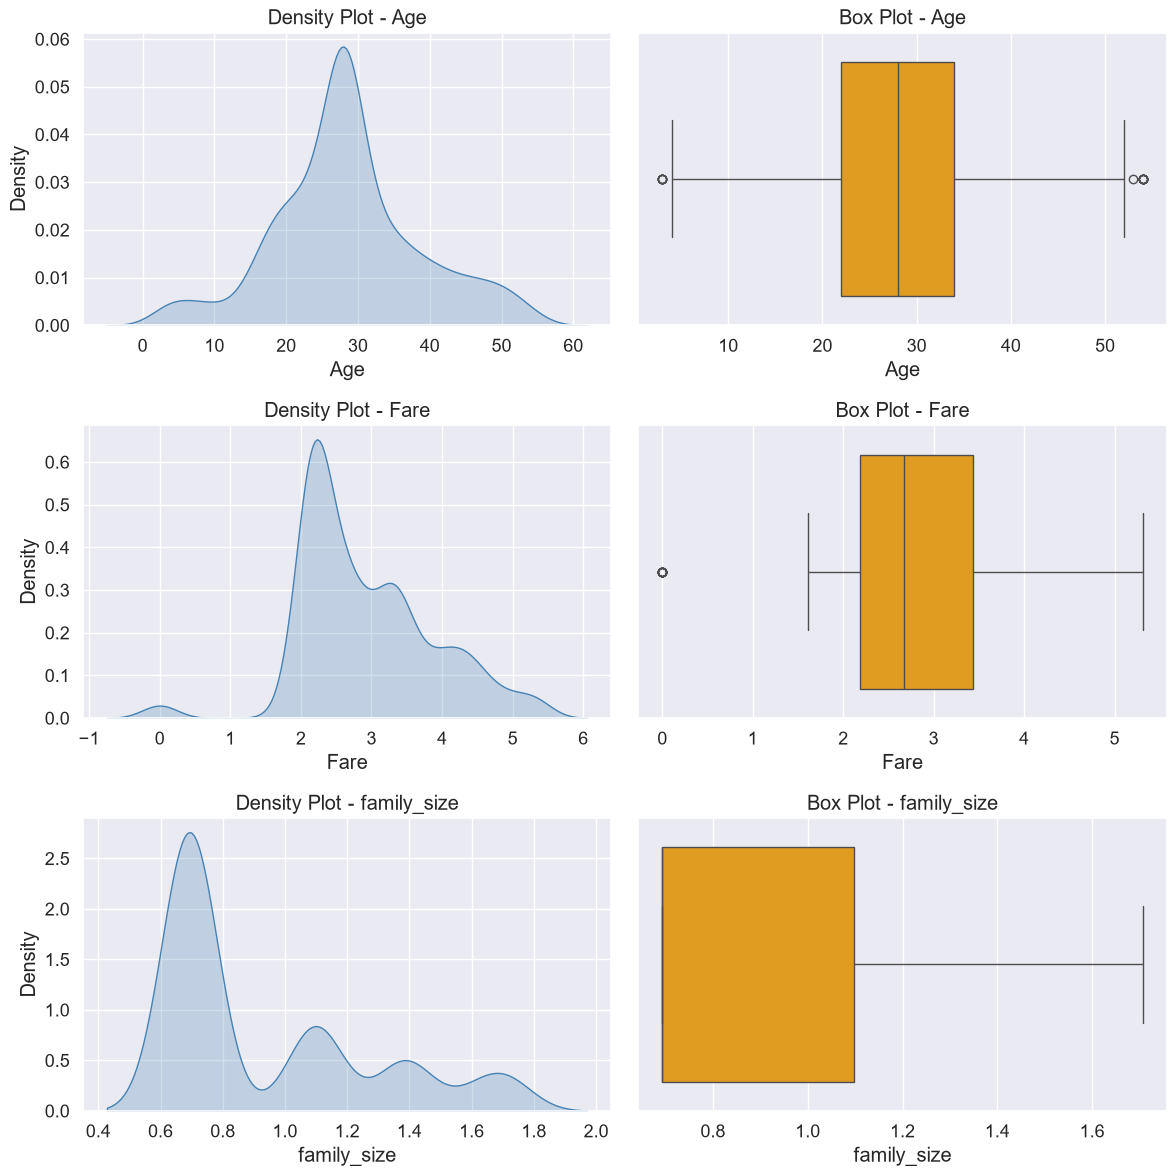

In [182]:

continuous_cols = ['Age', 'Fare', 'family_size']
fig, axes = plt.subplots(len(continuous_cols), 2, figsize=(12, 4 * len(continuous_cols)))

if len(continuous_cols) == 1:
    axes = axes.reshape(1, 2)

for i, c in enumerate(continuous_cols):
    sns.kdeplot(data=cleaned_df, x=c, fill=True, ax=axes[i, 0], color="steelblue")
    axes[i, 0].set_title(f"Density Plot - {c}")
    
    sns.boxplot(x=cleaned_df[c], ax=axes[i, 1], color="orange")
    axes[i, 1].set_title(f"Box Plot - {c}")
    axes[i, 1].set_xlabel(c)

plt.tight_layout()
plt.show()

In [183]:
cleaned_df.describe()

,Survived,Pclass,Sex,Age,Fare,Embarked,nobel,family_size,is_alone
count,825.000000,825.000000,825.000000,825.000000,825.000000,825.000000,825.000000,825.000000,825.000000
mean,0.380606,2.341818,0.356364,28.515152,2.923882,0.361212,0.056970,0.935852,0.612121
std,0.485830,0.824096,0.479215,10.177256,0.954606,0.638907,0.231925,0.338818,0.487562
min,0.000000,1.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.693147,0.000000
25%,0.000000,2.000000,0.000000,22.000000,2.185579,0.000000,0.000000,0.693147,0.000000
50%,0.000000,3.000000,0.000000,28.000000,2.668387,0.000000,0.000000,0.693147,1.000000
75%,1.000000,3.000000,1.000000,34.000000,3.436268,1.000000,0.000000,1.098612,1.000000
max,1.000000,3.000000,1.000000,54.000000,5.312302,2.000000,1.000000,1.706810,1.000000


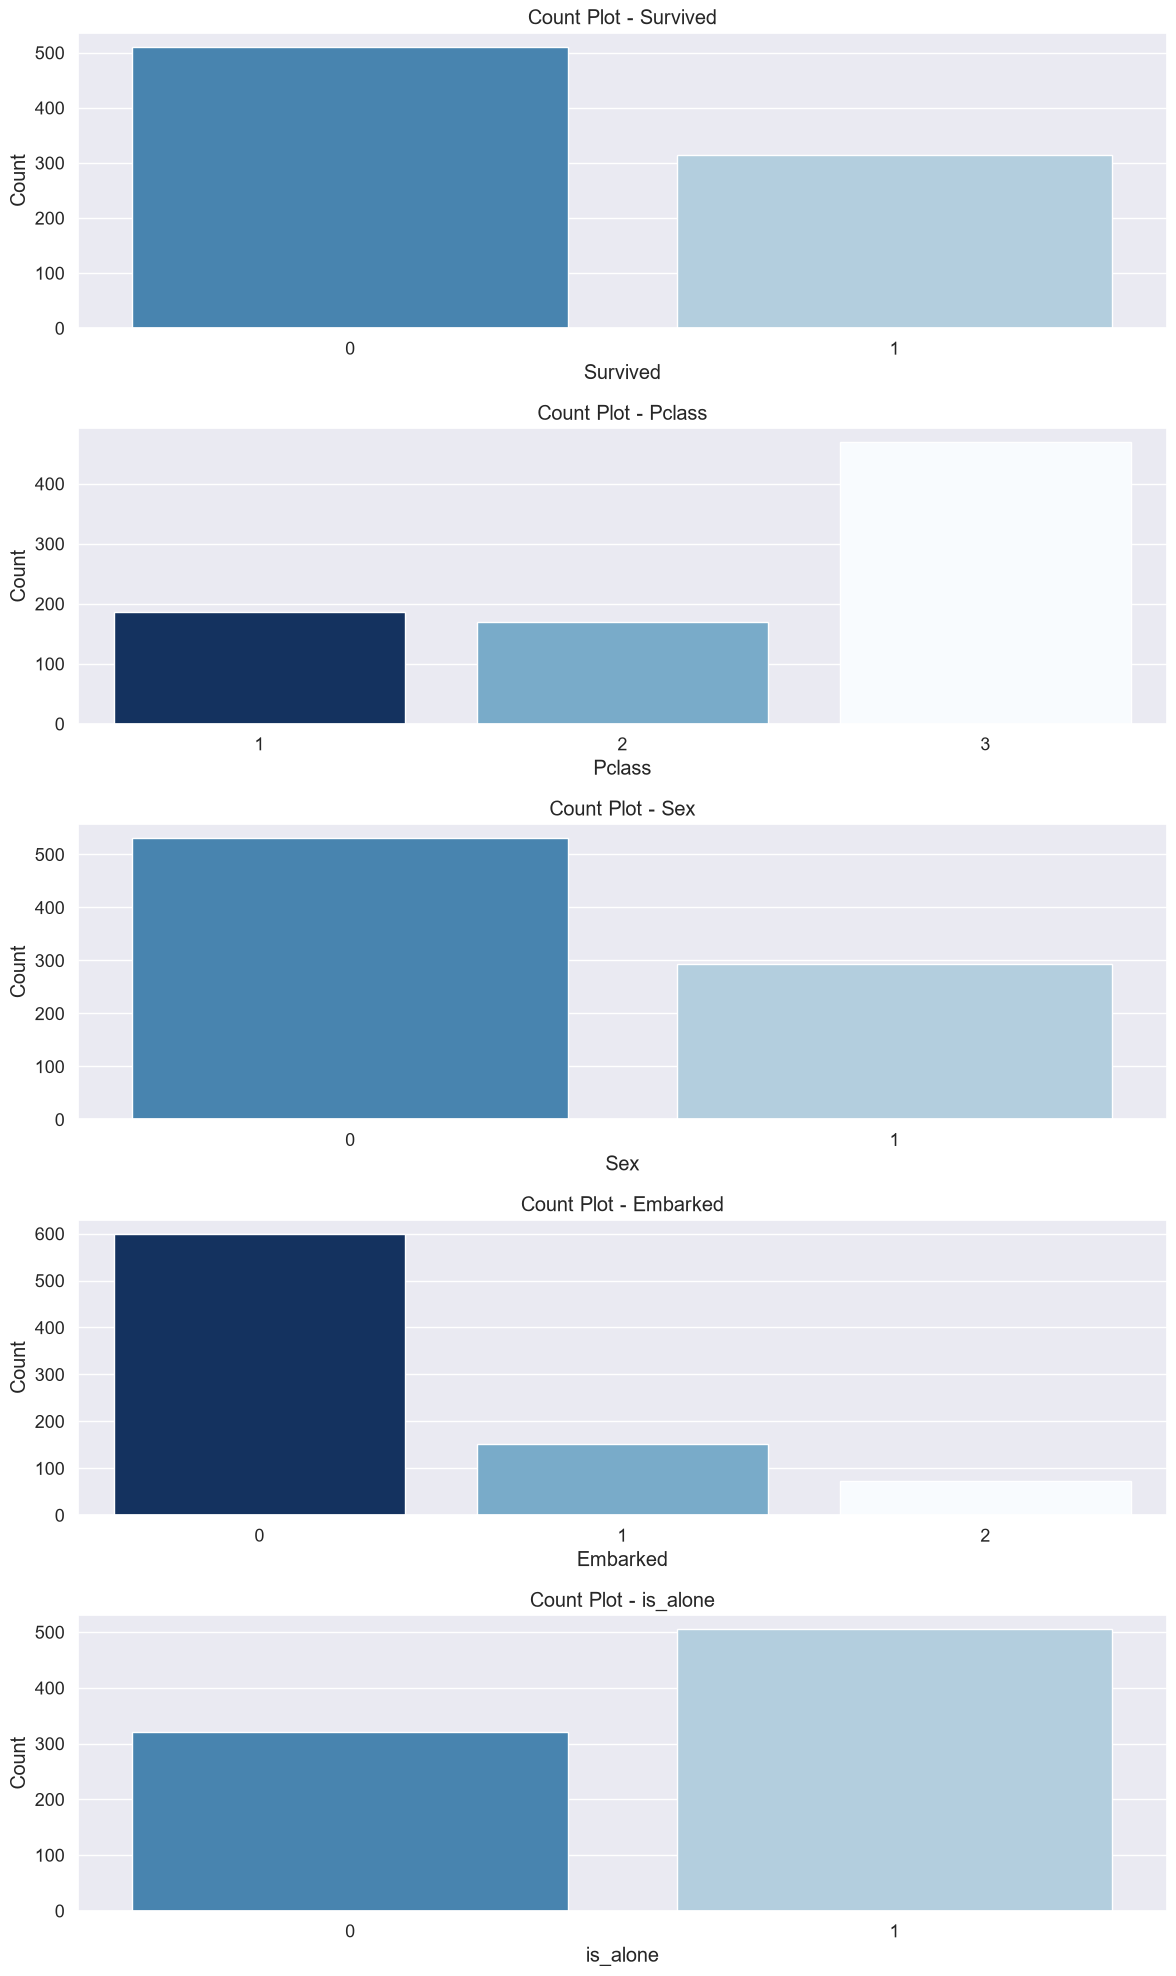

In [184]:
discrete_cols = ['Survived', 'Pclass', 'Sex','Embarked','is_alone']

fig, axes = plt.subplots(len(discrete_cols), 1, figsize=(12, 4 * len(discrete_cols)))

if len(discrete_cols) == 1:
    axes = [axes]

for i, c in enumerate(discrete_cols):
    # Count plot showing frequencies of each category
    sns.countplot(data=cleaned_df, x=c, ax=axes[i], palette="Blues_r", hue=c, legend=False)
    axes[i].set_title(f"Count Plot - {c}")
    axes[i].set_xlabel(c)
    axes[i].set_ylabel("Count")

plt.tight_layout()
plt.show()


In [185]:
# save the cleaned dataset to a new CSV file
cleaned_df.to_csv('./cleaned_titanic_data.csv', index=False)